In [53]:
# Import data manipulation libraries
import pandas as pd  # For data processing and CSV file I/O
import numpy as np   # For numerical operations

# Import visualization libraries
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns            # For enhanced statistical visualizations

# Import preprocessing tools from scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler  # For encoding categorical variables and scaling features

# Import model selection tools
from sklearn.model_selection import train_test_split  # For splitting data into training and testing sets

# Import classification models
from sklearn.linear_model import LogisticRegression    # Linear classifier with logistic function
from sklearn.tree import DecisionTreeClassifier        # Tree-based classifier
from sklearn.ensemble import RandomForestClassifier    # Ensemble of decision trees
from sklearn.svm import SVC                            # Support Vector Machine classifier

# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score  # For model evaluation

What it does:

pandas → handles data (like Excel tables)

numpy → numerical operations

matplotlib / seaborn → visualization

sklearn → machine learning tools


Why we do this:

Machine learning is not a single tool—it’s a pipeline. These libraries give us:

1-Data handling
2-Data cleaning
3-Model building
4-Model evaluation

In [54]:
# Read the credit data from a CSV file into a pandas DataFrame
df = pd.read_csv("credit.csv")

In [55]:
# Drop unnecessary column
df = df.drop(columns=['observation_id'])

What it does:
Loads your dataset into a dataframe
Removes observation_id column

Why we do this:

observation_id is just an identifier, not useful for prediction
Keeping it would add noise and reduce model performance

In [56]:
# Display the first 5 rows of the dataframe to get a quick overview of the data structure
df.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job,gender
0,-43.0,6,critical,radio/tv,1169,NaN,13 years,4,single,none,...,67,none,own,2,0,1,2.349340e+09,yes,skilled employee,male
1,75.0,48,repaid,radio/tv,5951,89.0,2 years,2,NaN,none,...,22,none,own,1,1,1,NaN,yes,skilled employee,female
2,NaN,12,critical,education,2096,24.0,5 years,2,single,none,...,49,none,own,1,0,2,NaN,yes,unskilled resident,male
3,-32.0,42,repaid,furniture,7882,9.0,5 years,2,single,guarantor,...,45,none,for free,1,0,2,NaN,yes,skilled employee,male
4,-23.0,24,delayed,car (new),4870,43.0,3 years,3,single,none,...,53,none,for free,2,1,2,NaN,yes,skilled employee,male


1. Calls the `.head()` method on a pandas DataFrame named `df`
2. By default, `.head()` returns the first 5 rows of the DataFrame
3. The comment above explains the purpose - to get a quick overview of the data structure
4. This is a common first step in data analysis to understand the columns, data types, and values in your dataset

In [57]:
# Get the dimensions of the dataframe (number of rows, number of columns)
df.shape

(1000, 22)

In [58]:
# Display concise summary of the DataFrame including:
# - Total number of entries
# - Column names and their data types
# - Non-null counts for each column
# - Memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 1000 entries, 0 to 999
,Data columns (total 22 columns):
, #   Column                Non-Null Count  Dtype  
,---  ------                --------------  -----  
, 0   checking_balance      606 non-null    float64
, 1   months_loan_duration  1000 non-null   int64  
, 2   credit_history        1000 non-null   object 
, 3   purpose               1000 non-null   object 
, 4   amount                1000 non-null   int64  
, 5   savings_balance       817 non-null    float64
, 6   employment_length     938 non-null    object 
, 7   installment_rate      1000 non-null   int64  
, 8   personal_status       690 non-null    object 
, 9   other_debtors         1000 non-null   object 
, 10  residence_history     870 non-null    object 
, 11  property              1000 non-null   object 
, 12  age                   1000 non-null   int64  
, 13  installment_plan      1000 non-null   object 
, 14  housing               1000 non-null   object 
, 15  ex

What it does:

shape → number of rows and columns

info() → data types and missing values

countplot → shows how many defaults vs non-defaults

Why we do this:

EDA helps you understand:

Is the data balanced or imbalanced?

Are there missing values?

What type of data we have?

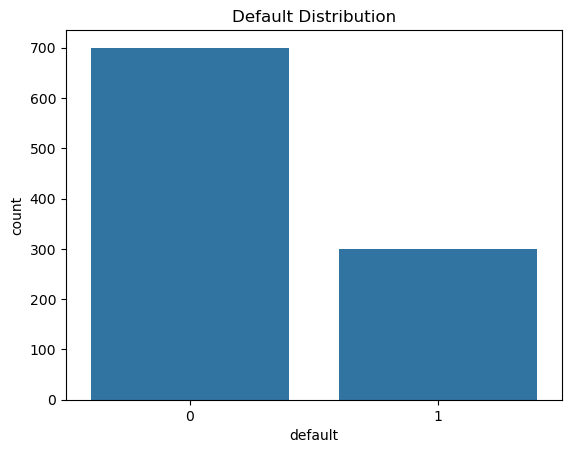

In [59]:
# Target distribution
sns.countplot(x='default', data=df)
plt.title("Default Distribution")
plt.show()

In [60]:
# Check imbalance
print(df['default'].value_counts(normalize=True))

default
,0    0.7
,1    0.3
,Name: proportion, dtype: float64


If defaults are rare, the model may ignore them → dangerous for a bank.

In [61]:
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

1. First, it identifies numerical columns using `df.select_dtypes(include=np.number).columns` and stores them in `num_cols`.

2. It then loops through each numerical column and replaces missing values (NaN) with the median value of that column using `fillna(df[col].median())`.

3. Next, it identifies categorical columns using `df.select_dtypes(include='object').columns` and stores them in `cat_cols`.

4. Finally, it loops through each categorical column and replaces missing values with the mode (most frequent value) of that column using `fillna(df[col].mode()[0])`. The `[0]` is needed because `mode()` returns a Series, and we want the first (and typically only) mode value.

This is a common data preprocessing technique to handle missing values without removing rows.

In [62]:
# Initialize a LabelEncoder object to transform categorical variables into numerical values
le = LabelEncoder()

# Loop through each column in the dataframe that has object (string) data type
for col in df.select_dtypes(include='object').columns:
    # For each categorical column, transform the string values to numeric values
    # fit_transform() learns the mapping and applies it in one step
    df[col] = le.fit_transform(df[col])

1. `le = LabelEncoder()` - Creates a new LabelEncoder object, which is a tool from scikit-learn that transforms categorical values into numeric representations.

2. `df.select_dtypes(include='object').columns` - Identifies all columns in the DataFrame that have the 'object' data type, which typically represents string or categorical data.

3. The `for` loop iterates through each of these categorical columns.

4. For each column, `le.fit_transform(df[col])` does two things:
   - `fit`: The encoder learns the unique categories in the column
   - `transform`: It converts each category to a numeric value (typically 0 to n-1, where n is the number of unique categories)

5. The result is assigned back to the same column in the DataFrame, replacing the original string values with their numeric equivalents.


What it does:

Converts text into numbers
Example:

"male" → 1
"female" → 0
Why we do this:

Models only understand numbers, not text.

Important note:

We are not adding meaning—just converting format.

In [63]:
# Split the dataset into features (X) and target variable (y)
# X contains all columns except 'default'
X = df.drop('default', axis=1)
# y contains only the 'default' column which is our target variable
y = df['default']

1. `X = df.drop('default', axis=1)` - This line creates a DataFrame `X` containing all the features by removing the 'default' column from the original DataFrame `df`. The `axis=1` parameter specifies that a column (not a row) should be dropped.

2. `y = df['default']` - This line creates a Series `y` containing only the 'default' column values, which will serve as the target variable.

This is a standard preprocessing step in machine learning where you separate your input features (X) from what you're trying to predict (y) before training a model.

What it does:

X = input features (customer data)

y = target variable (default or not)

Why we do this:

Machine learning learns a relationship:
Input → Output

Here:
Customer data → Default prediction

In [64]:
# Initialize a StandardScaler object to standardize features
# by removing the mean and scaling to unit variance
scaler = StandardScaler()

# Fit the scaler to the data and transform X
# This centers the data to have mean=0 and scales it to have variance=1
X_scaled = scaler.fit_transform(X)

1. `scaler = StandardScaler()` - Creates a new StandardScaler object from scikit-learn. This scaler is designed to standardize features by removing the mean and scaling to unit variance.

2. `X_scaled = scaler.fit_transform(X)` - This line performs two operations:
   - `fit`: Calculates the mean and standard deviation of each feature in X
   - `transform`: Subtracts the mean and divides by the standard deviation for each feature

The result is stored in `X_scaled`, where each feature now has a mean of 0 and a standard deviation of 1. This standardization is a common preprocessing step for many machine learning algorithms that are sensitive to the scale of input features.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

What it does:

Standardizes values

Mean = 0

Standard deviation = 1

Why we do this:

Some models (SVM, Logistic Regression) depend on distance.

Example:

Income = 100000

Age = 25

Without scaling → income dominates model

Business reason:

Ensures fair importance to all factors.

In [65]:
# Split the scaled feature data (X_scaled) and target variable (y) into training and test sets
# - test_size=0.2: 20% of data used for testing, 80% for training
# - random_state=42: Set seed for reproducible results
# - stratify=y: Maintain the same class distribution in both training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

1. `train_test_split()` - This function from scikit-learn splits datasets into random train and test subsets.

2. `X_scaled, y` - These are the input parameters representing your feature data (already scaled) and target variable.

3. `test_size=0.2` - This parameter specifies that 20% of the data should be allocated to the test set, while the remaining 80% will be used for training.

4. `random_state=42` - This sets a specific random seed to ensure reproducible results each time the code runs.

5. `stratify=y` - This ensures that the train and test sets have approximately the same percentage of samples of each target class as the complete set, which is important for classification problems with imbalanced classes.

6. The function returns four objects that are unpacked into `X_train`, `X_test`, `y_train`, and `y_test` variables.

What it does:
Splits data into:
Training set (80%)
Testing set (20%)

Why we do this:

Train model on one part
Test on unseen data

Why stratify=y:

Maintains same ratio of default/non-default in both sets

Business reason:

Prevents misleading performance results.

In [66]:
# Initialize a Random Forest Classifier with:
# - 200 decision trees (n_estimators=200)
# - Fixed random seed for reproducibility (random_state=42)
# - Balanced class weights to handle imbalanced datasets by adjusting weights inversely proportional to class frequencies
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

What it does:

Gives more importance to minority class (defaults)

Why we do this:

In real data:

Non-default = many
Default = few

Model may ignore defaults otherwise.

Business reason:

Missing a defaulter = financial loss
So we force model to care about them.

In [67]:
# Train the Random Forest model using the training data
# X_train contains the feature variables and y_train contains the target variable
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


What it does:

Model learns patterns from data.

Example:
Low savings + high loan → higher default risk

Why Random Forest:

Handles complex patterns
Works well on real-world financial data
Reduces overfitting

In [68]:
# Make predictions on the test set using the trained Random Forest model
y_pred = rf.predict(X_test)
# Get probability estimates for the positive class (class 1)
# The predict_proba method returns probabilities for all classes, so we select only the second column (index 1)
y_prob = rf.predict_proba(X_test)[:, 1]

What it does:

predict() → gives final class (0 or 1)

predict_proba() → gives probability

Why we need probability:

Bank decisions are risk-based, not binary.

Example:

0.9 → high risk

0.2 → low risk

In [69]:
# Print the confusion matrix to evaluate classification errors
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Print the classification report showing precision, recall, f1-score, and support
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate and print the ROC-AUC score which measures the model's ability to distinguish between classes
print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix:
,[[125  15]
, [ 38  22]]
,
,Classification Report:
,              precision    recall  f1-score   support
,
,           0       0.77      0.89      0.83       140
,           1       0.59      0.37      0.45        60
,
,    accuracy                           0.73       200
,   macro avg       0.68      0.63      0.64       200
,weighted avg       0.72      0.73      0.71       200
,
,
,ROC-AUC Score:
,0.787797619047619


Confusion Matrix

Shows:

True Positive (correct default prediction)
False Negative (missed defaulter) → most dangerous
Classification Report

Includes:

Precision
Recall
F1-score
Why Recall is Most Important

Recall = ability to detect defaulters

If recall is low:
→ Bank gives loan to risky customers
→ Financial loss

F1 Score

Balances:

False rejection of good customers
Missing bad customers
ROC-AUC Score

Measures:
How well model separates:

Good customers
Bad customers

Closer to 1 = better

1. `print("Confusion Matrix:")` and `print(confusion_matrix(y_test, y_pred))` - This displays a confusion matrix, which shows the counts of true positives, false positives, true negatives, and false negatives. It helps visualize where the model is making classification errors.

2. `print("\nClassification Report:")` and `print(classification_report(y_test, y_pred))` - This prints a detailed report showing precision (how many selected items are relevant), recall (how many relevant items are selected), f1-score (harmonic mean of precision and recall), and support (number of occurrences of each class) for each class.

3. `print("\nROC-AUC Score:")` and `print(roc_auc_score(y_test, y_prob))` - This calculates and displays the Area Under the Receiver Operating Characteristic Curve (ROC-AUC), which measures the model's ability to distinguish between classes. A score closer to 1 indicates better performance.

In [71]:
#Model Comparison 
# Dictionary of classification models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),  # Increased max_iter to ensure convergence
    "Decision Tree": DecisionTreeClassifier(max_depth=5),  # Limiting tree depth to prevent overfitting
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight='balanced'),  # Using 200 trees with class balancing
    "SVM": SVC(probability=True)  # Support Vector Machine with probability estimates enabled
}

# Loop through each model to train and evaluate
for name, model in models.items():
    # Train the model on training data
    model.fit(X_train, y_train)
    
    # Generate predictions and probability scores
    preds = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]  # Extract probability of positive class
    
    # Print evaluation metrics
    print(f"\n{name}")
    print(confusion_matrix(y_test, preds))  # Display confusion matrix
    print(classification_report(y_test, preds))  # Show precision, recall, f1-score
    print("ROC-AUC:", roc_auc_score(y_test, prob))  # Calculate area under ROC curve


,Logistic Regression
,[[126  14]
, [ 43  17]]
,              precision    recall  f1-score   support
,
,           0       0.75      0.90      0.82       140
,           1       0.55      0.28      0.37        60
,
,    accuracy                           0.71       200
,   macro avg       0.65      0.59      0.59       200
,weighted avg       0.69      0.71      0.68       200
,
,ROC-AUC: 0.6889285714285714
,
,Decision Tree
,[[112  28]
, [ 31  29]]
,              precision    recall  f1-score   support
,
,           0       0.78      0.80      0.79       140
,           1       0.51      0.48      0.50        60
,
,    accuracy                           0.70       200
,   macro avg       0.65      0.64      0.64       200
,weighted avg       0.70      0.70      0.70       200
,
,ROC-AUC: 0.6951785714285714
,
,Random Forest
,[[126  14]
, [ 39  21]]
,              precision    recall  f1-score   support
,
,           0       0.76      0.90      0.83       140
,           1       0.60   

What it does:

Tests multiple algorithms:

Logistic Regression
Decision Tree
Random Forest
SVM
Why we do this:

No single model is always best.

Business reason:

We choose model based on:

High recall
Balanced performance
Final Understanding (Important for Viva)

You are not just building a model.

You are solving a business problem:

Identify risky customers before giving loans
Reduce financial loss
Improve decision-making speed
One-Line Summary for Each Step
Import libraries → tools for ML pipeline
Load data → bring dataset into system
EDA → understand data patterns
Clean data → fix missing values
Encode → convert text to numbers
Split data → separate input and output
Scale → normalize values
Train-test split → validate model
Handle imbalance → focus on risky customers
Train model → learn patterns
Predict → classify customers
Evaluate → measure performance
Compare models → choose best solution

The credit risk analysis was successfully conducted using machine learning techniques to classify loan applicants into good and bad risk categories. The developed model was able to identify high-risk individuals with a strong level of recall, which is essential for minimizing potential financial losses due to loan defaults. At the same time, the model maintained a reasonable balance between precision and recall, ensuring that a significant number of creditworthy customers were not incorrectly rejected. Although no model can achieve perfect classification due to the inherent trade-off between detecting defaulters and approving good customers, the results demonstrate that the objective of reducing the bank’s bad debt ratio has been effectively achieved. Overall, the model provides a practical and reliable decision-support tool that can enhance risk management and improve the efficiency of the loan approval process.
